In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import pickle

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
# active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()

In [3]:
lc_active = scit.tl.make_layer_config('neighborhood_meth_active', feature_active_threshold=0, in_obsm=True)
active_meth = scit.adv.binary_active_feature(cttag, lc_active)

In [ ]:
# cttag.obsm['acet_imp'] = cttag.obsm['acet_imp'][:,active_meth].copy()
# cttag.obsm['meth_imp'] = cttag.obsm['meth_imp'][:,active_meth].copy()
# cttag.uns['gene_names_acet'] = cttag.uns['gene_names_acet'][active_meth]
# len(cttag.uns['gene_names_acet'])

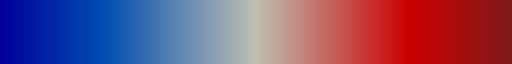

In [4]:
cmap_g = scit.adv.pl.custom_cmap('with_color')
cmap_bwr = scit.adv.pl.custom_cmap('bwr')
cmap_bwr

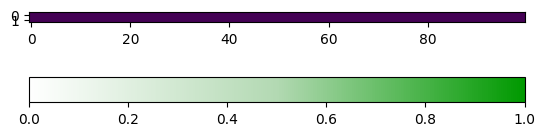

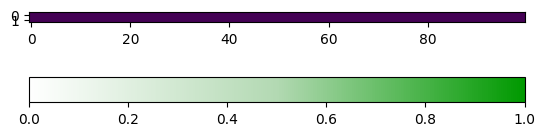

In [5]:
scit.adv.pl.draw_cbar(cmap_g)
#cmap_g
#splt.gcf().savefig('private/newest/cbar_green.pdf')

In [6]:
lc_acet = scit.tl.make_layer_config(
    "acet_imp",
    in_obsm=True,
    normalize_with_obs_counts=True,
    log_transform=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth_imp",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

Info: Added Griddata to .uns[cat_label]


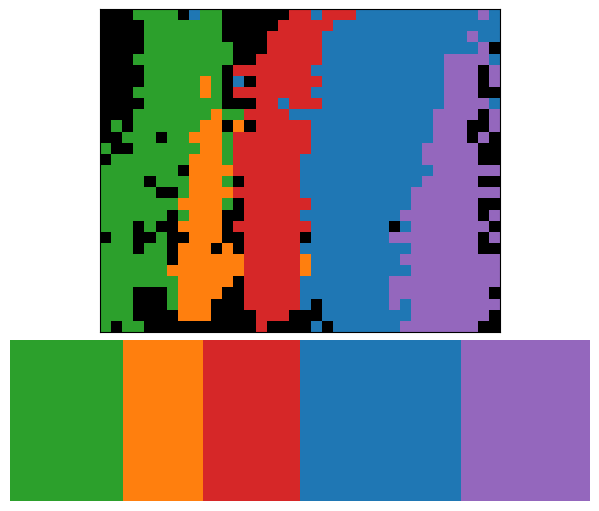

In [7]:
scit.adv.griddata_categorical(cttag, 'label', 8)
scit.adv.pl.categorical2d(cttag, 'cat_label')

In [8]:
scit.adv.griddata_numerical(cttag, lc_meth, min_cells=8, use_cached_mask=False)
scit.adv.griddata_numerical(cttag, lc_acet, min_cells=8, use_cached_mask=False)

Info: Added Griddata to .uns[meth_imp]
Info: Added Griddata to .uns[acet_imp]


In [13]:
trs = dict(
    gauss_kernel=(1.5,1.5), upscale_factor=2, n_median_passes=1
)

scit.adv.griddata_apply_transformations(cttag, lc_meth.layer, **trs)
scit.adv.griddata_apply_transformations(cttag, lc_acet.layer, **trs)


t_acet = f"t_{lc_acet.layer}"
t_meth = f"t_{lc_meth.layer}"

from copy import deepcopy
cttag.uns['griddata']['t_epi'] = deepcopy(cttag.uns['griddata'][t_meth])
SCL = 0.5
cttag.uns['griddata']['t_epi']['z'] = 10*cttag.uns['griddata'][t_meth]['z'] - 10*cttag.uns['griddata'][t_acet]['z']*SCL

Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_meth_imp]
Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_acet_imp]


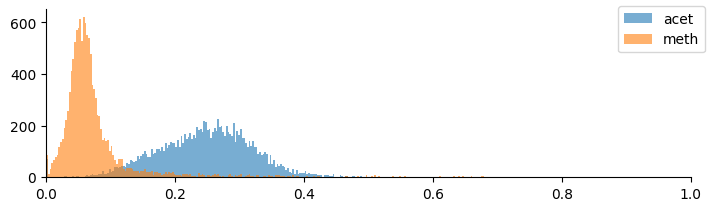

In [14]:
scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram(
    [
    cttag.uns['griddata'][t_acet]['z'].mean(axis=(1,2)),
    cttag.uns['griddata'][t_meth]['z'].mean(axis=(1,2))
    ],
    [
        'acet', 'meth'
    ], xminmax=(0,1), bins=300
)

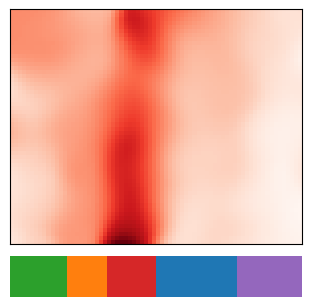

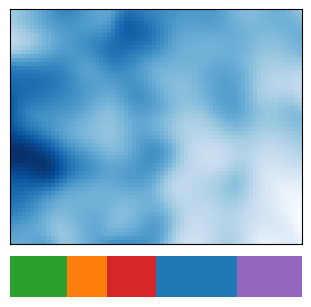

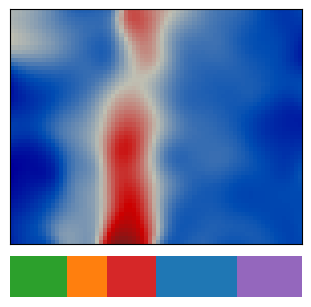

In [15]:
scit.set_defaults(figsize=(3,3))

gn = "nau"

scit.adv.pl.landscape2d(cttag, t_meth, gn, cmap='Reds')
scit.adv.pl.landscape2d(cttag, t_acet, gn, cmap='Blues')
scit.adv.pl.landscape2d(cttag, 't_epi', gn, cmap=cmap_bwr)

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


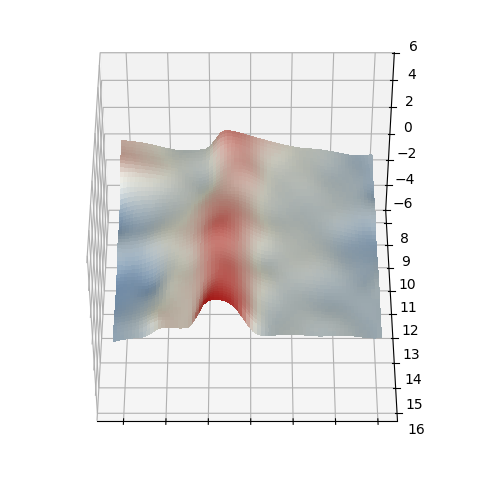

In [17]:
scit.set_defaults(figsize=(3,3))
scit.adv.pl.landscape3d(cttag.uns['griddata']['t_epi'], gn, cmap=cmap_bwr, vminmax=(-6,6))
import matplotlib.pyplot as plt
#plt.gcf().savefig(f'private/newest/screenshots/{gn}.png', dpi=300)

In [23]:
#from copy import deepcopy
#cttag.uns['griddata']['acet_metabin'] = deepcopy(cttag.uns['griddata']['t_acet'])
#cttag.uns['griddata']['acet_metabin']['z'] = cttag.uns['griddata']['acet_metabin']['z']

In [24]:
mt_lsc = ad.read_h5ad('private/data/clean_method/mutant_landscape.h5ad')

In [27]:
mt_lsc.obsm['acet_imp'] = mt_lsc.obsm['acet_imp'][:,active_meth].copy()
mt_lsc.obsm['meth_imp'] = mt_lsc.obsm['meth_imp'][:,active_meth].copy()
#mt_lsc.uns['gene_names_acet'] = mt_lsc.uns['gene_names_acet'][active_meth]

Info: Added Griddata to .uns[cat_label]


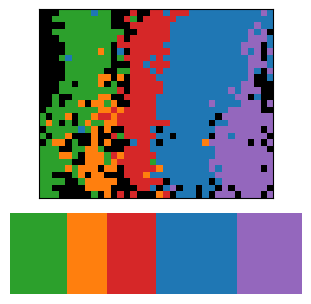

In [28]:
scit.adv.same_grid((cttag, mt_lsc))
scit.adv.griddata_categorical(mt_lsc, 'label', 5)
scit.adv.pl.categorical2d(mt_lsc, 'cat_label')

In [29]:
scit.adv.griddata_numerical(mt_lsc, lc_meth, min_cells=8, use_cached_mask=False)
scit.adv.griddata_numerical(mt_lsc, lc_acet, min_cells=8, use_cached_mask=False)

Info: Added Griddata to .uns[meth_imp]
Info: Added Griddata to .uns[acet_imp]


In [30]:
scit.adv.griddata_apply_transformations(mt_lsc, lc_meth.layer, **trs)
scit.adv.griddata_apply_transformations(mt_lsc, lc_acet.layer, **trs)
from copy import deepcopy
mt_lsc.uns['griddata']['t_epi'] = deepcopy(mt_lsc.uns['griddata'][t_meth])
mt_lsc.uns['griddata']['t_epi']['z'] = mt_lsc.uns['griddata'][t_meth]['z'] - mt_lsc.uns['griddata'][t_acet]['z']*SCL

Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_meth_imp]
Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_acet_imp]


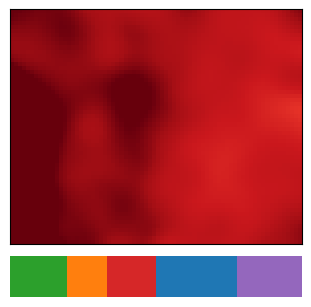

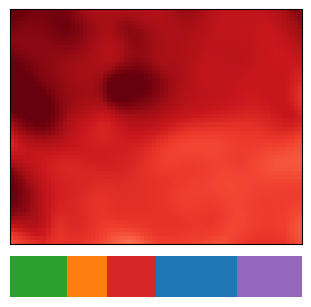

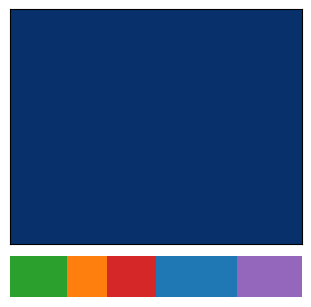

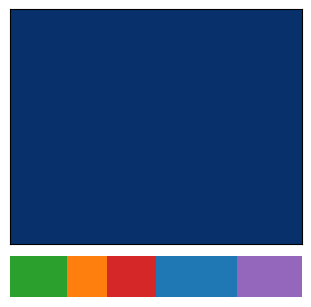

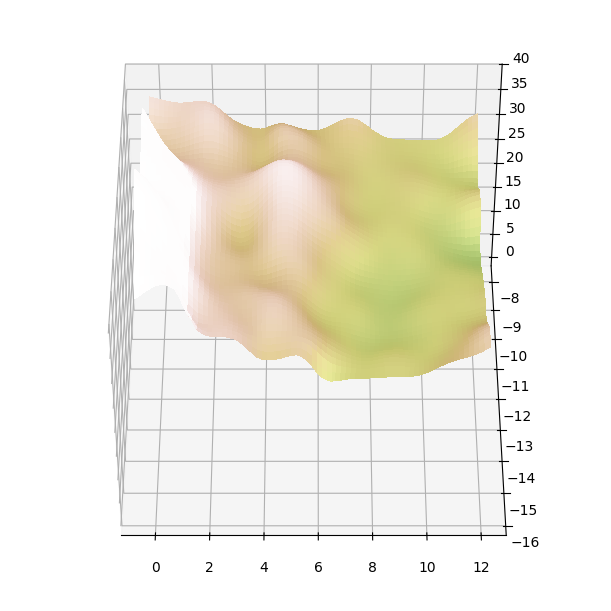

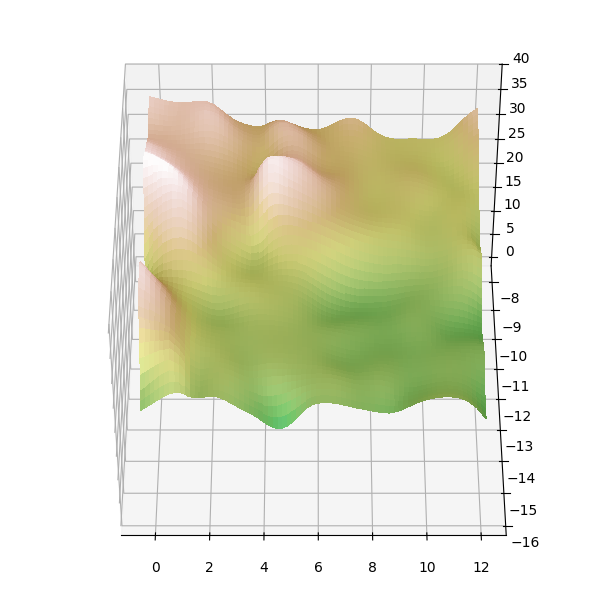

In [37]:
scit.set_defaults(figsize=(3,3))
gn = 'slp2'
vmx=(-2,40)
vmx_u=(0,40)
vmx_a=(0,2)

scit.adv.pl.landscape2d(cttag, t_meth, gn, cmap='Reds', vminmax=vmx_u)
scit.adv.pl.landscape2d(mt_lsc, t_meth, gn, cmap='Reds', vminmax=vmx_u)
scit.adv.pl.landscape2d(cttag, t_acet, gn, cmap='Blues', vminmax=vmx_a)
scit.adv.pl.landscape2d(mt_lsc, t_acet, gn, cmap='Blues', vminmax=vmx_a)

scit.adv.pl.landscape3d(cttag.uns['griddata']['t_epi'], gn, cmap='gist_earth', vminmax=vmx)
scit.adv.pl.landscape3d(mt_lsc.uns['griddata']['t_epi'], gn, cmap='gist_earth', vminmax=vmx)

In [ ]:
scit.set_defaults(figsize=(3,3))
from src.advanced._griddata import _get_griddata_z
import matplotlib.pyplot as plt
gns = cttag.uns['gene_names_acet'][active_meth]# [582:] #[active_meth]

for gn in gns:
    _z = _get_griddata_z(cttag.uns['griddata']['t_epi'], gn)
    vmx = (_z.min()-2, _z.max()+2)
    scit.adv.pl.landscape3d(cttag, 't_epi', gn, cmap='gist_earth', vminmax=vmx)
    f = plt.gcf()
    f.savefig(f'private/newest/lands/{gn}_wt.png')
    scit.adv.pl.landscape3d(mt_lsc, 't_epi', gn, cmap='gist_earth', vminmax=vmx)
    f = plt.gcf()
    f.savefig(f'private/newest/lands/{gn}_mt.png')
    plt.close('all')
    import gc; gc.collect()

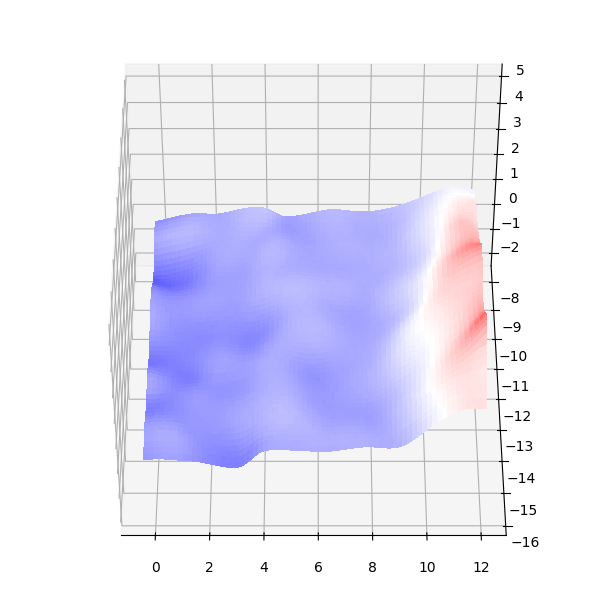

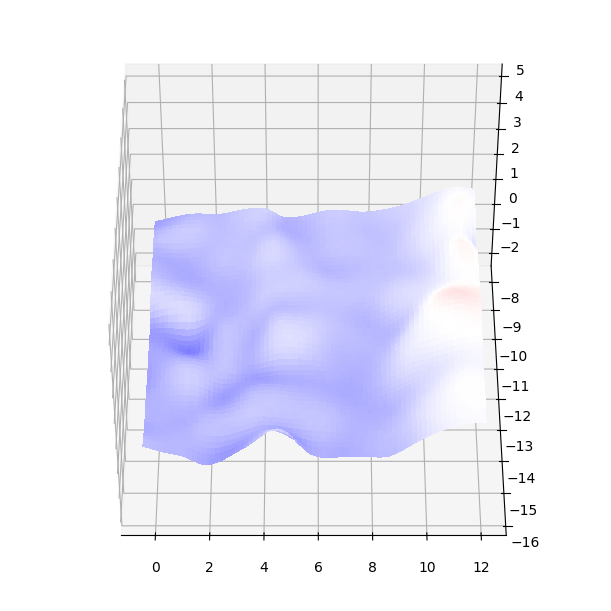

In [20]:
from src.advanced._griddata import _get_griddata_z
scit.set_defaults(figsize=(2,2))
gn = 'ACC'

_z = _get_griddata_z(cttag.uns['griddata']['t_epi'], gn)
vmx = (_z.min()-2, _z.max()+2)
#_max = max(-_z.min(), _z.max()) + 1
#vmx = (-_max, _max)
scit.adv.pl.landscape3d(cttag, 't_epi', gn, cmap='bwr', vminmax=vmx)
scit.adv.pl.landscape3d(mt_lsc, 't_epi', gn, cmap='bwr', vminmax=vmx)


In [ ]:
df=pl.read_csv('private/data/methylated_metagene_memberships.csv')
memberships=dict(zip(df['index'], df['leiden']))
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
scit.tl.layer_pick_features(mt_lsc, lc_meth, list(memberships.keys()))
scit.tl.layer_pick_features(mt_lsc, lc_acet, list(memberships.keys()))
assert np.all(lc_meth.get_feature_names() == list(memberships.keys()))
assert np.all(lc_acet.get_feature_names() == list(memberships.keys()))

from src.tools._inference import matrix_from_memberships, infer_layer
R=matrix_from_memberships(memberships)
sf = np.array([str(r) for r in range(R.shape[0])])
infer_layer(mt_lsc, R, lc_acet, sf, 'metabin_acet', use_cached_mask=True)
infer_layer(mt_lsc, R, lc_meth, sf, 'metabin_meth', use_cached_mask=True)

lc_acet = scit.tl.make_layer_config(
    "metabin_acet",
    in_obsm=True,
    feature_names=mt_lsc.uns['gene_names_metabin_acet']
)
lc_meth = scit.tl.make_layer_config(
    "metabin_meth",
    in_obsm=True,
    feature_names=mt_lsc.uns['gene_names_metabin_acet']
)
scit.tl.layer_pick_features(mt_lsc, lc_meth, mt_lsc.uns['gene_names_metabin_acet'])
scit.tl.layer_pick_features(mt_lsc, lc_acet, mt_lsc.uns['gene_names_metabin_acet'])
scit.adv.griddata_numerical(mt_lsc, lc_meth, min_cells=8)
scit.adv.griddata_numerical(mt_lsc, lc_acet, min_cells=8)
scit.adv.griddata_apply_transformations(mt_lsc, lc_meth.layer, (2,2), upscale_factor=2, n_median_passes=1)
scit.adv.griddata_apply_transformations(mt_lsc, lc_acet.layer, (2,2), upscale_factor=2, n_median_passes=1)

Info: Added Griddata to .uns[metabin_meth]
Info: Added Griddata to .uns[metabin_acet]
Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_metabin_meth]
Info: Scaling by 2x: from (36, 29) to (72, 58)
Info: Added Griddata to .uns[t_metabin_acet]


In [ ]:
from copy import deepcopy
mt_lsc.uns['griddata']['t_metabin_epi'] = deepcopy(mt_lsc.uns['griddata']['t_metabin_meth'])
mt_lsc.uns['griddata']['t_metabin_epi']['z'] = mt_lsc.uns['griddata']['t_metabin_meth']['z'] - mt_lsc.uns['griddata']['t_metabin_acet']['z']*2

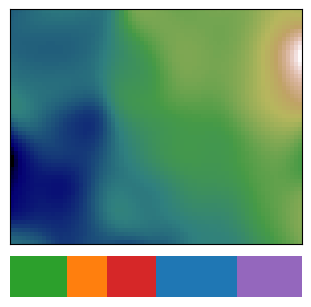

In [ ]:
scit.adv.pl.landscape2d(mt_lsc, 't_metabin_meth', '0', cmap='gist_earth')

In [ ]:
scit.set_defaults(figsize=(3,3))
import matplotlib.pyplot as plt

for a in mt_lsc.uns['gene_names_metabin_meth']:
    scit.adv.pl.landscape2d(mt_lsc, 't_metabin_epi', a, cmap='gist_earth')
    f = plt.gcf()
    f.savefig(f'private/newest/metabin/{a}_epi_mut.png')
    plt.close('all')